In [1]:
library(SingleCellExperiment)
library(dplyr)
library(ggplot2)
library(nichenetr)
library(multinichenetr)
library(data.table) #to read gz file

Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading required package: matrixStats


Attaching package: ‘MatrixGenerics’


The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollapse, rowCounts, rowCummaxs, rowCummins, rowCumprods,
    rowCumsums, rowDiffs, rowIQRDiffs, rowIQRs, rowLogSumExps,
    rowMadDiffs, rowMads, rowMaxs, rowMeans2, rowMedians, rowMins,
    rowOrderStats, rowProds, rowQuantiles, rowRanges

In [2]:
db_dir <- "/work/project/ladcol_011/MariaWF/community-paper/src/method_comparison/compare_algorithms/prepare_data/run_NicheNet/build_customDB/NNET_Custom/"
input_dir <- "/work/project/ladcol_011/MariaWF/community-paper/src/data_preprocessing/Lasry/2.filtering/outs/"


In [3]:
organism = "human"
if(organism == "human"){
  lr_network = readRDS(paste0(db_dir,"lig_rec_sources.rds"))
  lr_network = lr_network %>% dplyr::rename(ligand = from, receptor = to) %>% distinct(ligand, receptor) %>% mutate(ligand = make.names(ligand), receptor = make.names(receptor))
  ligand_target_matrix = readRDS(paste0(db_dir,"ligand_target_matrixWithweights.rds"))
  colnames(ligand_target_matrix) = colnames(ligand_target_matrix) %>% make.names()
  rownames(ligand_target_matrix) = rownames(ligand_target_matrix) %>% make.names()
} else if(organism == "mouse"){
  lr_network = readRDS(url("https://zenodo.org/record/7074291/files/lr_network_mouse_21122021.rds"))
  lr_network = lr_network %>% dplyr::rename(ligand = from, receptor = to) %>% distinct(ligand, receptor) %>% mutate(ligand = make.names(ligand), receptor = make.names(receptor))
  ligand_target_matrix = readRDS(url("https://zenodo.org/record/7074291/files/ligand_target_matrix_nsga2r_final_mouse.rds"))
  colnames(ligand_target_matrix) = colnames(ligand_target_matrix) %>% make.names()
  rownames(ligand_target_matrix) = rownames(ligand_target_matrix) %>% make.names()
}

In [4]:
dim(lr_network)

[1] 6941    2

In [5]:
# # load counts
# print("load counts")
# counts <- read.table(gzfile(paste0(path_in,"/counts_corr.csv.gz")
#                             )
#                      ,sep = ","
#                      ,row.names = 1
#                      ,header = TRUE
#                      )
# # load counts

counts <- fread(paste0(input_dir,"counts_lognorm.csv.gz"), header = TRUE,check.names=FALSE)
counts <- as.data.frame(counts)
rownames(counts) <- counts$gene_symbol
counts <- counts[,-1]
# head(str(counts))
# print(str(counts))

# load cell annotation
print("load cell annotation")
anno_cells <- read.table(paste0(input_dir,"anno_cells_norm.txt")
                         ,sep = "\t"
                         # ,row.names = 1
                         ,header = TRUE
                         )
# print(str(anno_cells))


counts_mat <- as.matrix(counts)


colnames(counts_mat) <- anno_cells$cell_ID
rownames(anno_cells) <- anno_cells$cell_ID

sce <- SingleCellExperiment(
  assays = list(counts = counts_mat),
  colData = anno_cells
)

sce

[1] "load cell annotation"


class: SingleCellExperiment 
dim: 15770 46702 
metadata(0):
assays(1): counts
rownames(15770): AL627309.5 LINC01409 ... AC004556.3 AC007325.4
rowData names(0):
colnames(46702): 2020.09.15.AML0024.CATCAAGGTTAGCGGA
  2020.09.15.AML0024.CATCAAGTCCGAGAAG ...
  2019.08.29.count.1.CGCATGGCAGGTCAGA
  2019.08.29.count.2.CGCATGGTCCGTGCGA
colData names(92): sample_ID cell ... total_counts_raw_cf_ctf_gf
  total_counts_raw_cf_ctf_gf_sf
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):

In [6]:
print(str(counts))

'data.frame':	15770 obs. of  46702 variables:
 $ X2020.09.15.AML0024.CATCAAGGTTAGCGGA           : num  0 0 0 0 0 0 0 0 0 0 ...
 $ X2020.09.15.AML0024.CATCAAGTCCGAGAAG           : num  0 0 0 0 0 0 0 0 0 0 ...
 $ X2020.09.15.AML0024.CATCCACAGGGACCAT           : num  0 0 0 0 0 ...
 $ X2020.09.15.AML0024.CCTCAACAGAGCAAGA           : num  0 0 0 0 0 0 0 0 0 0 ...
 $ X2020.09.15.AML0024.CCTCAACAGTTCCATG           : num  0 0.993 0 0 0 ...
 $ X2020.09.15.AML0024.CCTCAACGTAGAATAC           : num  0 0 0 0 0 0 0 0 0 0 ...
 $ X2020.09.15.AML0024.CCTCAACGTTCTCCCA           : num  0 0 0 0 0 0 0 0 0 0 ...
 $ X2020.09.15.AML0024.CCTCAACTCCGAACGC           : num  0 0 0 0 0 ...
 $ X2020.09.15.AML0024.CCTCAACTCTAGTCAG           : num  0 0 0 0 0 0 0 0 0 0 ...
 $ X2020.09.15.AML0024.CCTCACAAGACAGTCG           : num  0 0 0 0 0 0 0 0 0 0 ...
 $ X2020.09.15.AML0024.CCTCACACAATTGCCA           : num  0 0 0 0 0 0 0 0 0 0 ...
 $ X2020.09.15.AML0024.CCTCACACAGAACTAA           : num  0 0 0 0 0 0 0 0 0 0 ...
 $ X2020

In [7]:
sce = alias_to_symbol_SCE(sce, "human") %>% makenames_SCE()

[1] "there are provided symbols that are not in the alias annotation table: "
   [1] "AL627309.5"     "AL645608.2"     "AL162741.1"     "AL391244.2"    
   [5] "AL645728.1"     "AL691432.4"     "AL691432.2"     "FO704657.1"    
   [9] "AL590822.2"     "AL590822.3"     "AL513477.2"     "AL139246.5"    
  [13] "AL031848.2"     "AL139424.3"     "AL109811.2"     "AL109811.1"    
  [17] "AL021155.5"     "AL031283.1"     "AL450998.2"     "AL109627.1"    
  [21] "AL137802.2"     "BX284668.5"     "BX284668.6"     "AL031432.1"    
  [25] "AL031432.4"     "AL031432.3"     "AL031280.1"     "AL020996.1"    
  [29] "AL020997.2"     "AL353622.1"     "AL360012.1"     "AL451070.1"    
  [33] "AL136115.2"     "AL445248.1"     "AL049795.1"     "AC004865.2"    
  [37] "AL139286.3"     "AL591845.1"     "AL139260.1"     "AL356055.1"    
  [41] "AL033527.3"     "AL033527.4"     "AL050341.2"     "AL512353.1"    
  [45] "AL139289.2"     "AL357079.1"     "AL139220.2"     "AL592182.3"    
  [49] "AL050343.2"   

In [8]:
sample_id = "sample_ID"
group_id = "health_status"
celltype_id = "cell_type"
covariates = NA
batches = NA

In [9]:
SummarizedExperiment::colData(sce)[,celltype_id] %>% unique()

[1] "Mono" "Gran" "T"    "NK"   "B"    "HSPC" "Ery"  "DC"

In [10]:
covariates = NA
batches = NA

In [11]:
SummarizedExperiment::colData(sce)$sample_ID = SummarizedExperiment::colData(sce)$sample_ID %>% make.names()
SummarizedExperiment::colData(sce)$health_status = SummarizedExperiment::colData(sce)$health_status %>% make.names()

In [12]:
contrasts_oi = c("'healthy-AML','AML-healthy'")

contrast_tbl = tibble(
  contrast = c("healthy-AML","AML-healthy"), 
  group = c("healthy","AML"))

In [13]:
senders_oi = SummarizedExperiment::colData(sce)[,celltype_id] %>% unique()
receivers_oi = SummarizedExperiment::colData(sce)[,celltype_id] %>% unique()

sce = sce[, SummarizedExperiment::colData(sce)[,celltype_id] %in% c(senders_oi, receivers_oi)]


In [14]:
min_cells = 6

In [15]:
abundance_info = get_abundance_info(
  sce = sce, 
  sample_id = sample_id, group_id = group_id, celltype_id = celltype_id, 
  min_cells = min_cells, 
  senders_oi = senders_oi, receivers_oi = receivers_oi, 
  batches = batches
  )

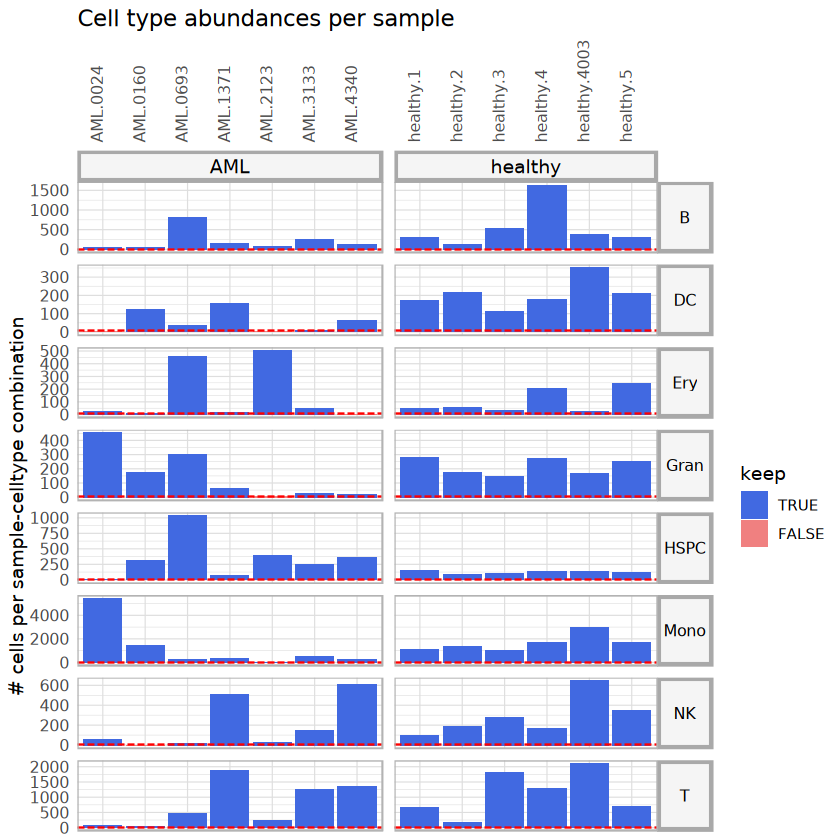

In [16]:
abundance_info$abund_plot_sample

In [17]:
sample_group_celltype_df = abundance_info$abundance_data %>% 
  filter(n > min_cells) %>% 
  ungroup() %>% 
  distinct(sample_id, group_id) %>% 
  cross_join(
    abundance_info$abundance_data %>% 
      ungroup() %>% 
      distinct(celltype_id)
    ) %>% 
  arrange(sample_id)

abundance_df = sample_group_celltype_df %>% left_join(
  abundance_info$abundance_data %>% ungroup()
  )

abundance_df$n[is.na(abundance_df$n)] = 0
abundance_df$keep[is.na(abundance_df$keep)] = FALSE
abundance_df_summarized = abundance_df %>% 
  mutate(keep = as.logical(keep)) %>% 
  group_by(group_id, celltype_id) %>% 
  summarise(samples_present = sum((keep)))

celltypes_absent_one_condition = abundance_df_summarized %>% 
  filter(samples_present == 0) %>% pull(celltype_id) %>% unique() 
# find truly condition-specific cell types by searching for cell types 
# truely absent in at least one condition

celltypes_present_one_condition = abundance_df_summarized %>% 
  filter(samples_present >= 2) %>% pull(celltype_id) %>% unique() 
# require presence in at least 2 samples of one group so 
# it is really present in at least one condition

condition_specific_celltypes = intersect(
  celltypes_absent_one_condition, 
  celltypes_present_one_condition)

total_nr_conditions = SummarizedExperiment::colData(sce)[,group_id] %>% 
  unique() %>% length() 

absent_celltypes = abundance_df_summarized %>% 
  filter(samples_present < 2) %>% 
  group_by(celltype_id) %>% 
  count() %>% 
  filter(n == total_nr_conditions) %>% 
  pull(celltype_id)
  
print("condition-specific celltypes:")
## [1] "condition-specific celltypes:"
print(condition_specific_celltypes)
## character(0)
  
print("absent celltypes:")
## [1] "absent celltypes:"
print(absent_celltypes)
## character(0)

Joining with `by = join_by(sample_id, group_id, celltype_id)`
`summarise()` has grouped output by 'group_id'. You can override using the `.groups` argument.


[1] "condition-specific celltypes:"
character(0)
[1] "absent celltypes:"
character(0)


In [18]:
min_sample_prop = 0.60
fraction_cutoff = 0.10

In [19]:
frq_list = get_frac_exprs(
  sce = sce, 
  sample_id = sample_id, celltype_id =  celltype_id, group_id = group_id, 
  batches = batches, 
  min_cells = min_cells, 
  fraction_cutoff = fraction_cutoff, min_sample_prop = min_sample_prop)

Warning message in get_frac_exprs(sce = sce, sample_id = sample_id, celltype_id = celltype_id, :
“There are some genes with NA/NaN fraction of expression. This is the result of the muscat function `calcExprFreqs` which will give NA/NaN when there are no cells of a particular cell type in a particular group or no cells of a cell type in one sample. As a temporary fix, we give all these genes an expression fraction of 0 in that group for that cell type”
Joining with `by = join_by(sample, group)`


[1] "Samples are considered if they have more than 6 cells of the cell type of interest"


Joining with `by = join_by(sample, celltype)`


[1] "Genes with non-zero counts in at least 10% of cells of a cell type of interest in a particular sample will be considered as expressed in that sample."
[1] "Genes expressed in at least 3.6 samples will considered as expressed in the cell type: B"
[1] "Genes expressed in at least 3 samples will considered as expressed in the cell type: DC"
[1] "Genes expressed in at least 3.6 samples will considered as expressed in the cell type: Ery"
[1] "Genes expressed in at least 3.6 samples will considered as expressed in the cell type: Gran"
[1] "Genes expressed in at least 3.6 samples will considered as expressed in the cell type: HSPC"
[1] "Genes expressed in at least 3.6 samples will considered as expressed in the cell type: Mono"
[1] "Genes expressed in at least 3.6 samples will considered as expressed in the cell type: NK"
[1] "Genes expressed in at least 3.6 samples will considered as expressed in the cell type: T"


Joining with `by = join_by(sample)`
Joining with `by = join_by(celltype)`
Joining with `by = join_by(sample, celltype, group)`


[1] "3628 genes are considered as expressed in the cell type: B"
[1] "6442 genes are considered as expressed in the cell type: DC"
[1] "8941 genes are considered as expressed in the cell type: Ery"
[1] "6865 genes are considered as expressed in the cell type: Gran"
[1] "8063 genes are considered as expressed in the cell type: HSPC"
[1] "5318 genes are considered as expressed in the cell type: Mono"
[1] "3700 genes are considered as expressed in the cell type: NK"
[1] "3693 genes are considered as expressed in the cell type: T"


In [20]:
genes_oi = frq_list$expressed_df %>% 
  filter(expressed == TRUE) %>% pull(gene) %>% unique() 
sce = sce[genes_oi, ]

In [21]:
empirical_pval = FALSE

logFC_threshold = 2
p_val_threshold = 0.05
p_val_adj = FALSE 

top_n_target = 250
n.cores = 8

In [22]:
scenario = "regular"

In [23]:
ligand_activity_down = FALSE

In [24]:
multinichenet_output = multi_nichenet_analysis(
  sce = sce, 
  celltype_id = celltype_id, sample_id = sample_id, group_id = group_id, 
  batches = batches, covariates = covariates, 
  lr_network = lr_network, ligand_target_matrix = ligand_target_matrix, 
  contrasts_oi = contrasts_oi, contrast_tbl = contrast_tbl, 
  senders_oi = senders_oi, receivers_oi = receivers_oi,
  min_cells = min_cells, 
  fraction_cutoff = fraction_cutoff, 
  min_sample_prop = min_sample_prop,
  scenario = scenario, 
  ligand_activity_down = ligand_activity_down,
  logFC_threshold = logFC_threshold, 
  p_val_threshold = p_val_threshold, 
  p_val_adj = p_val_adj, 
  empirical_pval = empirical_pval, 
  top_n_target = top_n_target, 
  n.cores = n.cores, 
  verbose = TRUE
  )

[1] "Cell type & sample filtering"
[1] "condition-specific celltypes:"
character(0)
[1] "absent celltypes:"
character(0)
[1] "Gene filtering"


Warning message in get_frac_exprs(sce = sce, sample_id = sample_id, celltype_id = celltype_id, :
“There are some genes with NA/NaN fraction of expression. This is the result of the muscat function `calcExprFreqs` which will give NA/NaN when there are no cells of a particular cell type in a particular group or no cells of a cell type in one sample. As a temporary fix, we give all these genes an expression fraction of 0 in that group for that cell type”
Joining with `by = join_by(sample, group)`


[1] "Samples are considered if they have more than 6 cells of the cell type of interest"


Joining with `by = join_by(sample, celltype)`


[1] "Genes with non-zero counts in at least 10% of cells of a cell type of interest in a particular sample will be considered as expressed in that sample."
[1] "Genes expressed in at least 3.6 samples will considered as expressed in the cell type: B"
[1] "Genes expressed in at least 3 samples will considered as expressed in the cell type: DC"
[1] "Genes expressed in at least 3.6 samples will considered as expressed in the cell type: Ery"
[1] "Genes expressed in at least 3.6 samples will considered as expressed in the cell type: Gran"
[1] "Genes expressed in at least 3.6 samples will considered as expressed in the cell type: HSPC"
[1] "Genes expressed in at least 3.6 samples will considered as expressed in the cell type: Mono"
[1] "Genes expressed in at least 3.6 samples will considered as expressed in the cell type: NK"
[1] "Genes expressed in at least 3.6 samples will considered as expressed in the cell type: T"


...

[1] "3628 genes are considered as expressed in the cell type: B"
[1] "6442 genes are considered as expressed in the cell type: DC"
[1] "8941 genes are considered as expressed in the cell type: Ery"
[1] "6865 genes are considered as expressed in the cell type: Gran"
[1] "8063 genes are considered as expressed in the cell type: HSPC"
[1] "5318 genes are considered as expressed in the cell type: Mono"
[1] "3700 genes are considered as expressed in the cell type: NK"
[1] "3693 genes are considered as expressed in the cell type: T"
[1] "Calculate normalized average and pseudobulk expression"


Warning message in DGEList.default(pb@assays@data[[celltype_oi]]):
“At least one library size is zero”
Warning message in DGEList.default(pb@assays@data[[celltype_oi]]):
“At least one library size is zero”
Warning message in DGEList.default(pb@assays@data[[celltype_oi]]):
“At least one library size is zero”
Joining with `by = join_by(sender, receiver, ligand, receptor)`
Joining with `by = join_by(sender, receiver, ligand, receptor)`
Joining with `by = join_by(sender, receiver, ligand, receptor)`


[1] "Calculate differential expression for all cell types"


Warning message in perform_muscat_de_analysis(sce = sce_oi, sample_id = sample_id, :
“non-integer library sizes: are you sure you are working with raw counts?”
Success for cell type: Mono

Warning message in perform_muscat_de_analysis(sce = sce_oi, sample_id = sample_id, :
“non-integer library sizes: are you sure you are working with raw counts?”
Success for cell type: Gran

Warning message in perform_muscat_de_analysis(sce = sce_oi, sample_id = sample_id, :
“non-integer library sizes: are you sure you are working with raw counts?”
Success for cell type: T

Warning message in perform_muscat_de_analysis(sce = sce_oi, sample_id = sample_id, :
“non-integer library sizes: are you sure you are working with raw counts?”
Success for cell type: NK

Warning message in perform_muscat_de_analysis(sce = sce_oi, sample_id = sample_id, :
“non-integer library sizes: are you sure you are working with raw counts?”
Success for cell type: B

Warning message in perform_muscat_de_analysis(sce = sce_oi, sam

[1] "DE analysis is done:"
[1] "included cell types are:"
[1] "Mono" "Gran" "T"    "NK"   "B"    "HSPC" "Ery"  "DC"  
[1] "retained cell types"
[1] "Mono" "Gran" "T"    "NK"   "B"    "HSPC" "Ery"  "DC"  
[1] "Calculate NicheNet ligand activities and ligand-target links"
[1] "Combine all the information in prioritization tables"
[1] "Calculate correlation between LR pairs and target genes"
[1] "There are no condition specific cell types in the data. MultiNicheNet analysis is performed in the regular way for all cell types."


In [3]:
save(multinichenet_output, file = "multinichenet_v2_outs.rda")

In [35]:
load("multinichenet_v2_outs.rda")

In [4]:
sample_df = multinichenet_output$prioritization_tables$sample_prioritization_tbl

In [5]:
unique(sample_df$keep_sender_receiver)

[1] Sender & Receiver present Sender absent            
[3] Receiver absent           Sender & Receiver absent 
4 Levels: Sender & Receiver absent Receiver absent ... Sender & Receiver present

In [25]:
sample_df = sample_df[sample_df$keep_sender_receiver == "Sender & Receiver present",]
sample_df$interaction_ID <- paste0(sample_df$sender, ":", sample_df$ligand, "_", sample_df$receiver, ":", sample_df$receptor)

ERROR: Error: object 'sample_df' not found


In [7]:
multinichenet_output$celltype_info$avg_df %>% head()

gene,sample,average_sample,celltype
<chr>,<chr>,<dbl>,<fct>
A4GALT,AML.0024,0.033953655,Mono
AAK1,AML.0024,0.615357126,Mono
ABCA1,AML.0024,0.033492177,Mono
ABCA2,AML.0024,0.009713095,Mono
ABCA7,AML.0024,0.065983786,Mono
ABCB10,AML.0024,0.036279900,Mono


In [26]:
df = multinichenet_output$prioritization_tables$group_prioritization_tbl
df$interaction_ID <- paste0(df$sender, ":", df$ligand, "_", df$receiver, ":", df$receptor)

In [27]:
df[df$interaction_ID == "Mono:HMGB1_T:CXCR4",]

contrast,group,sender,receiver,ligand,receptor,lr_interaction,id,scaled_lfc_ligand,scaled_p_val_ligand_adapted,scaled_lfc_receptor,scaled_p_val_receptor_adapted,max_scaled_activity,scaled_pb_ligand,scaled_pb_receptor,fraction_expressing_ligand_receptor,prioritization_score,top_group,interaction_ID
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
AML-healthy,AML,Mono,T,HMGB1,CXCR4,HMGB1_CXCR4,HMGB1_CXCR4_Mono_T,0.4493103,0.3855172,0.8910035,0.95761246,0.2180512,0.0010000,0.9798333,1,0.590101,AML,Mono:HMGB1_T:CXCR4
healthy-AML,healthy,Mono,T,HMGB1,CXCR4,HMGB1_CXCR4,HMGB1_CXCR4_Mono_T,0.5510345,0.6148276,0.1094291,0.04282007,NA,0.1971757,0.8912183,1,NA,AML,Mono:HMGB1_T:CXCR4


In [28]:
df[df$interaction_ID == "T:CALM1_Gran:HMMR",]

contrast,group,sender,receiver,ligand,receptor,lr_interaction,id,scaled_lfc_ligand,scaled_p_val_ligand_adapted,scaled_lfc_receptor,scaled_p_val_receptor_adapted,max_scaled_activity,scaled_pb_ligand,scaled_pb_receptor,fraction_expressing_ligand_receptor,prioritization_score,top_group,interaction_ID
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
healthy-AML,healthy,T,Gran,CALM1,HMMR,CALM1_HMMR,CALM1_HMMR_T_Gran,0.6343103,0.7877586,0.97685986,0.92279412,0.1629877,0.9576248,0.7092362,0.6666667,0.6928961,healthy,T:CALM1_Gran:HMMR
AML-healthy,AML,T,Gran,CALM1,HMMR,CALM1_HMMR,CALM1_HMMR_T_Gran,0.3660345,0.2125862,0.02357266,0.07763841,0.2617654,0.8742437,0.4855804,0.2857143,0.3745366,healthy,T:CALM1_Gran:HMMR


In [29]:
df[df$interaction_ID == "HSPC:CD34_T:SELL",]

contrast,group,sender,receiver,ligand,receptor,lr_interaction,id,scaled_lfc_ligand,scaled_p_val_ligand_adapted,scaled_lfc_receptor,scaled_p_val_receptor_adapted,max_scaled_activity,scaled_pb_ligand,scaled_pb_receptor,fraction_expressing_ligand_receptor,prioritization_score,top_group,interaction_ID
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
AML-healthy,AML,HSPC,T,CD34,SELL,CD34_SELL,CD34_SELL_HSPC_T,0.2175862,0.2820690,0.06141869,0.0666090,0.4442081,0.7725241,0.7032222,0.2857143,0.4199183,AML,HSPC:CD34_T:SELL
healthy-AML,healthy,HSPC,T,CD34,SELL,CD34_SELL,CD34_SELL_HSPC_T,0.7827586,0.7182759,0.93901384,0.9338235,NA,1.0010000,0.8449896,0.8333333,NA,AML,HSPC:CD34_T:SELL


In [30]:
dim(df)

[1] 28294    19

In [40]:
dim(df)

[1] 28294    19

In [30]:
library(dplyr)
library(tidyr)


Attaching package: ‘tidyr’


The following object is masked from ‘package:S4Vectors’:

    expand




In [36]:
# df[(df$scaled_p_val_ligand_adapted < 0.05) & (df$scaled_p_val_receptor_adapted < 0.05),]

In [41]:
group_prioritization_tbl = multinichenet_output$prioritization_tables$group_prioritization_tbl %>% dplyr::filter(group == top_group & fraction_expressing_ligand_receptor > 0)

In [42]:
lr_table = group_prioritization_tbl %>% dplyr::filter(group == top_group & fraction_expressing_ligand_receptor > 0) %>% dplyr::distinct(group, sender, receiver, ligand, receptor, receiver, id, prioritization_score)

In [43]:
dim(lr_table)

[1] 14104     7

In [34]:
head(lr_table)

group,sender,receiver,ligand,receptor,id,prioritization_score
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
healthy,Ery,Ery,STUB1,DNAJA3,STUB1_DNAJA3_Ery_Ery,0.9248390
AML,B,B,LGALS1,CD69,LGALS1_CD69_B_B,0.9227102
AML,HSPC,NK,CTSG,F2R,CTSG_F2R_HSPC_NK,0.9145840
AML,NK,B,LGALS1,CD69,LGALS1_CD69_NK_B,0.9068987
healthy,Gran,T,LGALS1,PTPRC,LGALS1_PTPRC_Gran_T,0.9042236
healthy,Mono,HSPC,THBS1,ITGA2B,THBS1_ITGA2B_Mono_HSPC,0.9025933


In [19]:
celltype_de = multinichenet_output$celltype_de

In [20]:
head(celltype_de)

gene,cluster_id,logFC,logCPM,F,p_val,p_adj.loc,p_adj,contrast
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
AAK1,Mono,-0.767,7.71,11.200,0.0039,0.253,0.253,healthy-AML
ABCA1,Mono,-0.444,6.60,0.373,0.5500,0.861,0.861,healthy-AML
ABHD14B,Mono,-0.680,5.98,3.890,0.0652,0.494,0.494,healthy-AML
ABHD5,Mono,0.650,7.19,4.040,0.0610,0.485,0.485,healthy-AML
ABTB1,Mono,0.155,6.29,0.264,0.6140,0.889,0.889,healthy-AML
AC002558.3,Mono,-0.391,5.90,2.220,0.4060,0.797,0.797,healthy-AML


In [21]:
df[df$interaction_ID == "HSPC:CD34_T:SELL",]

contrast,group,sender,receiver,ligand,receptor,lr_interaction,id,scaled_lfc_ligand,scaled_p_val_ligand_adapted,scaled_lfc_receptor,scaled_p_val_receptor_adapted,max_scaled_activity,scaled_pb_ligand,scaled_pb_receptor,fraction_expressing_ligand_receptor,prioritization_score,top_group,interaction_ID
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
healthy-AML,healthy,HSPC,T,CD34,SELL,CD34_SELL,CD34_SELL_HSPC_T,0.7827586,0.7182759,0.93901384,0.9338235,0.5240447,1.0010000,0.8449896,0.8333333,0.8150506,healthy,HSPC:CD34_T:SELL
AML-healthy,AML,HSPC,T,CD34,SELL,CD34_SELL,CD34_SELL_HSPC_T,0.2175862,0.2820690,0.06141869,0.0666090,0.7064659,0.7725241,0.7032222,0.2857143,0.4636280,healthy,HSPC:CD34_T:SELL


In [25]:
het_interactions = read.csv("/work/project/ladcol_011/MariaWF/community-paper/src/method_comparison/compare_algorithms/compare_results/het_interactions.csv")

In [27]:
het_df = df[df$interaction_ID %in% het_interactions$interaction_ID,]

In [31]:
het_df = het_df[!duplicated(het_df$interaction_ID),]

In [43]:
het_df = het_df[het_df$sender != het_df$receiver,]

In [45]:
het_df = het_df[, c(ncol(het_df), 1:(ncol(het_df)-1))]

In [59]:
het_df["send_ct_gene"] = paste(het_df$sender, het_df$ligand, sep="_")
het_df["rec_ct_gene"] = paste(het_df$receiver, het_df$receptor, sep="_")

In [62]:
s = het_df[het_df$send_ct_gene %in% celltype_de_$ct_gene,]

In [63]:
s[s$rec_ct_gene %in% celltype_de_$ct_gene,]

interaction_ID,contrast,group,sender,receiver,ligand,receptor,lr_interaction,id,scaled_lfc_ligand,⋯,scaled_lfc_receptor,scaled_p_val_receptor_adapted,max_scaled_activity,scaled_pb_ligand,scaled_pb_receptor,fraction_expressing_ligand_receptor,prioritization_score,top_group,send_ct_gene,rec_ct_gene
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
Mono:THBS1_Ery:LRP5,healthy-AML,healthy,Mono,Ery,THBS1,LRP5,THBS1_LRP5,THBS1_LRP5_Mono_Ery,0.9541379,⋯,0.9294983,0.9312284,0.5665354,1.0010000,1.0010000,1.0000000,0.9007360,healthy,Mono_THBS1,Ery_LRP5
HSPC:ITGA2B_Ery:ENG,healthy-AML,healthy,HSPC,Ery,ITGA2B,ENG,ITGA2B_ENG,ITGA2B_ENG_HSPC_Ery,0.9943103,⋯,0.8752163,0.9191176,0.4538310,1.0010000,1.0010000,1.0000000,0.8914048,healthy,HSPC_ITGA2B,Ery_ENG
HSPC:SMAP1_Ery:ENG,healthy-AML,healthy,HSPC,Ery,SMAP1,ENG,SMAP1_ENG,SMAP1_ENG_HSPC_Ery,0.8996552,⋯,0.8752163,0.9191176,0.7298189,0.7708004,1.0010000,1.0000000,0.8884471,healthy,HSPC_SMAP1,Ery_ENG
Ery:KIT_T:IL7R,healthy-AML,healthy,Ery,T,KIT,IL7R,KIT_IL7R,KIT_IL7R_Ery_T,0.9350000,⋯,0.9018166,0.9796713,0.5081477,0.8729985,1.0010000,1.0000000,0.8760564,healthy,Ery_KIT,T_IL7R
B:TGFB1_HSPC:LPP,AML-healthy,AML,B,HSPC,TGFB1,LPP,TGFB1_LPP,TGFB1_LPP_B_HSPC,0.9118966,⋯,0.9375000,0.9788062,0.7489146,0.6263670,0.8586342,1.0000000,0.8549856,AML,B_TGFB1,HSPC_LPP
Mono:THBS1_Ery:ITGA2B,healthy-AML,healthy,Mono,Ery,THBS1,ITGA2B,THBS1_ITGA2B,THBS1_ITGA2B_Mono_Ery,0.9541379,⋯,0.9731834,0.9580450,0.5665354,1.0010000,0.7991876,0.8333333,0.8451980,healthy,Mono_THBS1,Ery_ITGA2B
HSPC:IL1B_DC:IL1R2,healthy-AML,healthy,HSPC,DC,IL1B,IL1R2,IL1B_IL1R2,IL1B_IL1R2_HSPC_DC,0.9501724,⋯,0.9909170,0.9422578,0.6095694,0.8818524,1.0010000,0.6666667,0.8435609,healthy,HSPC_IL1B,DC_IL1R2
HSPC:PLXND1_Mono:SEMA4A,AML-healthy,AML,HSPC,Mono,PLXND1,SEMA4A,PLXND1_SEMA4A,PLXND1_SEMA4A_HSPC_Mono,0.9541379,⋯,0.8795415,0.9359862,0.4502603,1.0010000,1.0010000,0.7142857,0.8388505,AML,HSPC_PLXND1,Mono_SEMA4A
HSPC:ADAM17_Mono:ITGA5,AML-healthy,AML,HSPC,Mono,ADAM17,ITGA5,ADAM17_ITGA5,ADAM17_ITGA5_HSPC_Mono,0.9696552,⋯,0.8992215,0.8525087,0.2986377,0.8306038,1.0010000,1.0000000,0.8312764,AML,HSPC_ADAM17,Mono_ITGA5


In [53]:
celltype_de_ = celltype_de[abs(celltype_de$logFC) > 0.7,]

In [57]:
celltype_de_["ct_gene"] = paste(celltype_de_$cluster_id, celltype_de_$gene, sep="_")

In [69]:
celltype_de_[celltype_de_$gene == "VSTM1",]

gene,cluster_id,logFC,logCPM,F,p_val,p_adj.loc,p_adj,contrast,ct_gene
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
VSTM1,Mono,1.27,6.14,6.13,0.0243,0.394,0.394,healthy-AML,Mono_VSTM1
VSTM1,Mono,-1.27,6.14,6.13,0.0243,0.394,0.394,AML-healthy,Mono_VSTM1
VSTM1,Gran,1.54,5.51,7.14,0.0155,0.320,0.320,healthy-AML,Gran_VSTM1
VSTM1,Gran,-1.54,5.51,7.14,0.0155,0.320,0.320,AML-healthy,Gran_VSTM1


In [65]:
celltype_de_[celltype_de_$gene == "LRP5",]

gene,cluster_id,logFC,logCPM,F,p_val,p_adj.loc,p_adj,contrast,ct_gene
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
LRP5,Ery,0.971,4.69,6.41,0.0181,0.0679,0.0679,healthy-AML,Ery_LRP5
LRP5,Ery,-0.971,4.69,6.41,0.0181,0.0679,0.0679,AML-healthy,Ery_LRP5


In [21]:
df[df$interaction_ID == "T:CALM1_Gran:HMMR",]

contrast,group,sender,receiver,ligand,receptor,lr_interaction,id,scaled_lfc_ligand,scaled_p_val_ligand_adapted,scaled_lfc_receptor,scaled_p_val_receptor_adapted,max_scaled_activity,scaled_pb_ligand,scaled_pb_receptor,fraction_expressing_ligand_receptor,prioritization_score,top_group,interaction_ID
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
healthy-AML,healthy,T,Gran,CALM1,HMMR,CALM1_HMMR,CALM1_HMMR_T_Gran,0.6343103,0.7877586,0.97685986,0.92279412,0.4277331,0.9576248,0.7092362,0.6666667,0.7370204,healthy,T:CALM1_Gran:HMMR
AML-healthy,AML,T,Gran,CALM1,HMMR,CALM1_HMMR,CALM1_HMMR_T_Gran,0.3660345,0.2125862,0.02357266,0.07763841,0.5488235,0.8742437,0.4855804,0.2857143,0.4223796,healthy,T:CALM1_Gran:HMMR


In [22]:
celltype_de[celltype_de$gene == "CALM1",]

gene,cluster_id,logFC,logCPM,F,p_val,p_adj.loc,p_adj,contrast
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
CALM1,Mono,0.198,9.42,2.15,0.16200,0.6270,0.6270,healthy-AML
CALM1,Mono,-0.198,9.42,2.15,0.16200,0.6270,0.6270,AML-healthy
CALM1,Gran,0.547,9.49,9.30,0.00689,0.2400,0.2400,healthy-AML
CALM1,Gran,-0.547,9.49,9.30,0.00689,0.2400,0.2400,AML-healthy
CALM1,T,0.174,10.50,1.76,0.20100,0.5640,0.5640,healthy-AML
CALM1,T,-0.174,10.50,1.76,0.20100,0.5640,0.5640,AML-healthy
CALM1,NK,0.333,10.60,6.00,0.02540,0.5330,0.5330,healthy-AML
CALM1,NK,-0.333,10.60,6.00,0.02540,0.5330,0.5330,AML-healthy
CALM1,B,-0.263,9.97,3.26,0.08710,0.4410,0.4410,healthy-AML


In [23]:
celltype_de[celltype_de$gene == "HMMR",]

gene,cluster_id,logFC,logCPM,F,p_val,p_adj.loc,p_adj,contrast
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
HMMR,Gran,1.620,5.76,6.10,0.0237,0.352,0.352,healthy-AML
HMMR,Gran,-1.620,5.76,6.10,0.0237,0.352,0.352,AML-healthy
HMMR,Ery,-0.336,7.86,1.63,0.2140,0.375,0.375,healthy-AML
HMMR,Ery,0.336,7.86,1.63,0.2140,0.375,0.375,AML-healthy


In [19]:
dim(lr_table)

[1] 14104     7

In [24]:
result <- lr_table %>%
  left_join(celltype_de, by = c("receiver" = "cluster_id", "receptor" = "gene")) %>%
  mutate(match_found = !is.na(logFC)) %>%  # Check if a match was found (logFC is non-NA if matched)
  select(group, sender, receiver, ligand, receptor, id, prioritization_score, match_found, everything())

Warning message in left_join(., celltype_de, by = c(receiver = "cluster_id", receptor = "gene")):
“Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 1 of `x` matches multiple rows in `y`.
ℹ Row 20294 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship = "many-to-many"` to silence this warning.”


In [25]:
result[result$match_found == FALSE,]

group,sender,receiver,ligand,receptor,id,prioritization_score,match_found,logFC,logCPM,F,p_val,p_adj.loc,p_adj,contrast
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>


In [26]:
dim(lr_table[lr_table$receptor %in% celltype_de$gene,])

[1] 14104     7

In [29]:
dim(lr_table[lr_table$ligand %in% celltype_de$gene,])

[1] 14104     7

In [202]:
prioritization_tbl_oi = prioritization_tbl_oi %>% dplyr::group_by(group) %>% dplyr::mutate(prioritization_rank = rank(desc(prioritization_score))) %>% dplyr::filter(prioritization_rank <= top_n)

ERROR: Error: object 'prioritization_tbl_oi' not found


In [203]:
prioritized_tbl_oi_all = get_top_n_lr_pairs(
  multinichenet_output$prioritization_tables, 
  top_n = 50, 
  rank_per_group = FALSE
  )

In [204]:
prioritized_tbl_oi = 
  multinichenet_output$prioritization_tables$group_prioritization_tbl %>%
  filter(id %in% prioritized_tbl_oi_all$id) %>%
  distinct(id, sender, receiver, ligand, receptor, group) %>% 
  left_join(prioritized_tbl_oi_all)
prioritized_tbl_oi$prioritization_score[is.na(prioritized_tbl_oi$prioritization_score)] = 0

Joining with `by = join_by(id, sender, receiver, ligand, receptor, group)`


In [205]:
prioritized_tbl_oi[prioritized_tbl_oi$id == "LGALS9_CD44_Gran_Mono",]

id,sender,receiver,ligand,receptor,group,prioritization_score,prioritization_rank
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>
LGALS9_CD44_Gran_Mono,Gran,Mono,LGALS9,CD44,AML,0.8896549,37
LGALS9_CD44_Gran_Mono,Gran,Mono,LGALS9,CD44,healthy,0.0000000,NA


Joining with `by = join_by(sender)`
Joining with `by = join_by(receiver)`
Joining with `by = join_by(sender)`
Joining with `by = join_by(receiver)`


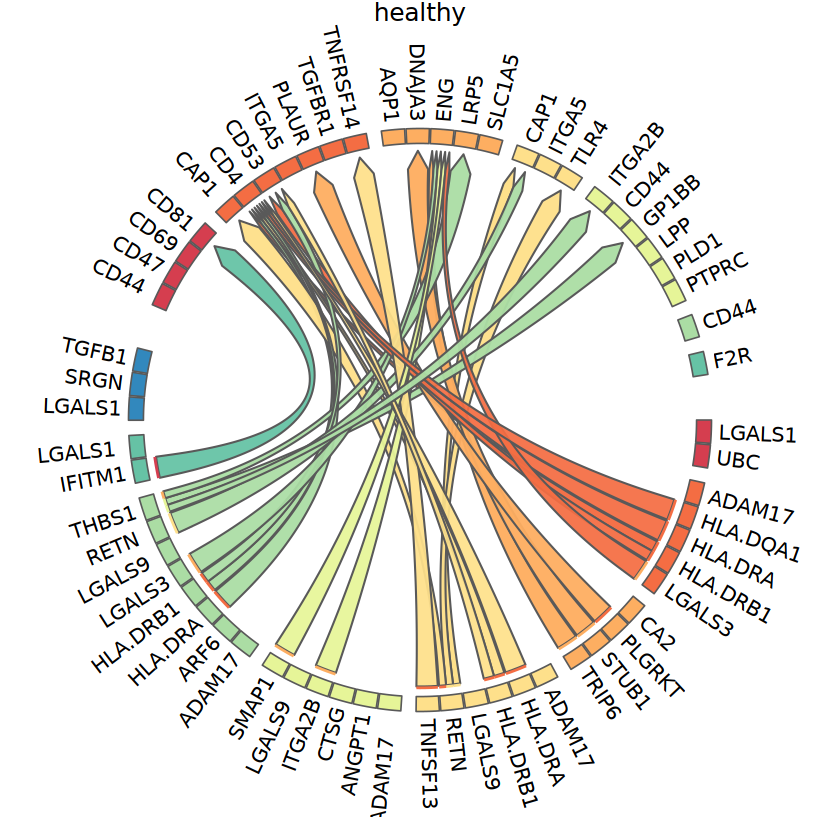

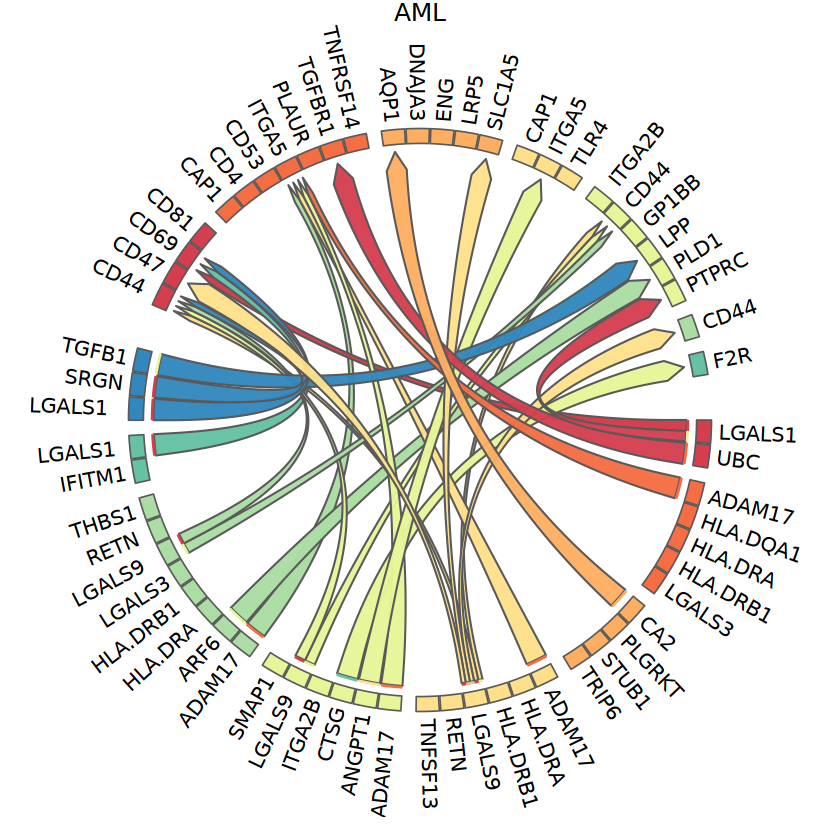

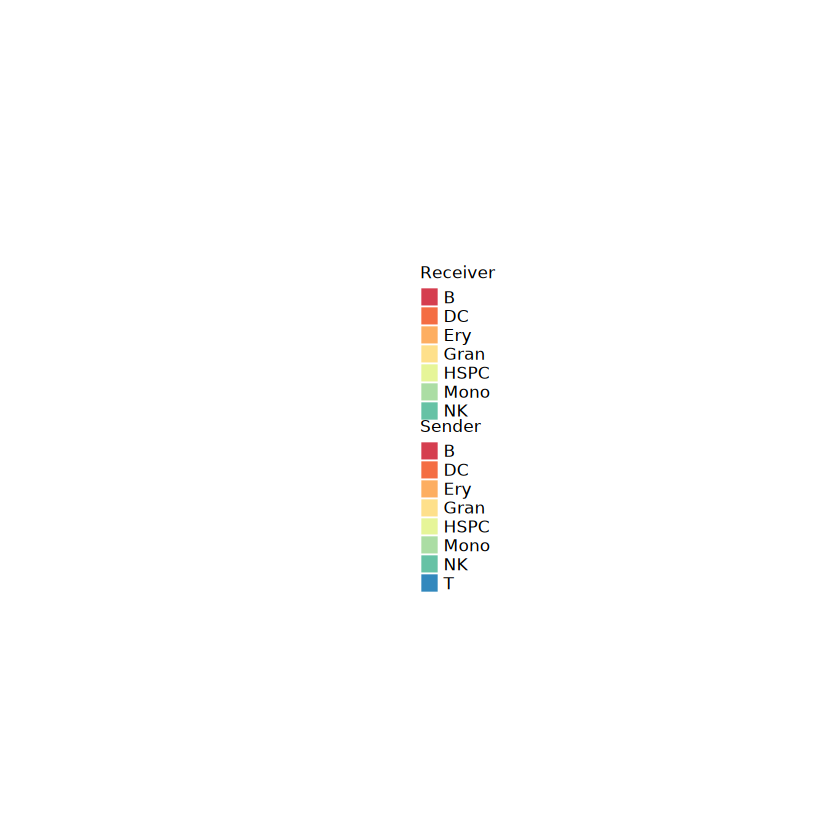

In [208]:
senders_receivers = union(prioritized_tbl_oi$sender %>% unique(), prioritized_tbl_oi$receiver %>% unique()) %>% sort()

colors_sender = RColorBrewer::brewer.pal(n = length(senders_receivers), name = 'Spectral') %>% magrittr::set_names(senders_receivers)
colors_receiver = RColorBrewer::brewer.pal(n = length(senders_receivers), name = 'Spectral') %>% magrittr::set_names(senders_receivers)

circos_list = make_circos_group_comparison(prioritized_tbl_oi, colors_sender, colors_receiver)

In [209]:
group_oi = "AML"

prioritized_tbl_oi_Tumor_50 = get_top_n_lr_pairs(
  multinichenet_output$prioritization_tables, 
  top_n = 15550, 
  groups_oi = group_oi)

In [69]:
# head(prioritized_tbl_oi_Tumor_50)

In [210]:
one = prioritized_tbl_oi_Tumor_50[prioritized_tbl_oi_Tumor_50$id == "HMGB1_CXCR4_Mono_T",]

In [211]:
# HMGB1_CXCR4_Mono_T
prioritized_tbl_oi_Tumor_50[prioritized_tbl_oi_Tumor_50$id == "HMGB1_CXCR4_Mono_T",]

group,sender,receiver,ligand,receptor,id,prioritization_score,prioritization_rank
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>
AML,Mono,T,HMGB1,CXCR4,HMGB1_CXCR4_Mono_T,0.6133584,4593


In [212]:
df[df$interaction_ID == "Ery:CD55_HSPC:ADGRE5",]

contrast,group,sender,receiver,ligand,receptor,lr_interaction,id,scaled_lfc_ligand,scaled_p_val_ligand_adapted,scaled_lfc_receptor,scaled_p_val_receptor_adapted,max_scaled_activity,scaled_pb_ligand,scaled_pb_receptor,fraction_expressing_ligand_receptor,prioritization_score,top_group,interaction_ID
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
AML-healthy,AML,Ery,HSPC,CD55,ADGRE5,CD55_ADGRE5,CD55_ADGRE5_Ery_HSPC,0.94172414,0.98551724,0.992647059,0.997837370,0.4367215,0.4714832,0.7978863,0.8571429,0.7536828,AML,Ery:CD55_HSPC:ADGRE5
healthy-AML,healthy,Ery,HSPC,CD55,ADGRE5,CD55_ADGRE5,CD55_ADGRE5_Ery_HSPC,0.05862069,0.01482759,0.007785467,0.002595156,0.7713466,0.0010000,0.3239037,1.0000000,0.3563608,AML,Ery:CD55_HSPC:ADGRE5


In [70]:
# sample_data = sample_df %>% dplyr::filter(id %in% one$id) %>% dplyr::mutate(sender_receiver = paste(sender, receiver, sep = " --> "), lr_interaction = paste(ligand, receptor, sep = " - "))   %>%  dplyr::arrange(receiver) %>% dplyr::group_by(receiver) %>%  dplyr::arrange(sender, .by_group = TRUE)
# sample_data = sample_data %>% dplyr::mutate(sender_receiver = factor(sender_receiver, levels = sample_data$sender_receiver %>% unique()))
  

In [71]:
df[df$id == "HMGB1_CXCR4_Mono_T",]

contrast,group,sender,receiver,ligand,receptor,lr_interaction,id,scaled_lfc_ligand,scaled_p_val_ligand_adapted,scaled_lfc_receptor,scaled_p_val_receptor_adapted,max_scaled_activity,scaled_pb_ligand,scaled_pb_receptor,fraction_expressing_ligand_receptor,prioritization_score,top_group,interaction_ID
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
AML-healthy,AML,Mono,T,HMGB1,CXCR4,HMGB1_CXCR4,HMGB1_CXCR4_Mono_T,0.4493103,0.3855172,0.8910035,0.95761246,0.3575952,0.0010000,0.9798333,1,0.6133584,AML,Mono:HMGB1_T:CXCR4
healthy-AML,healthy,Mono,T,HMGB1,CXCR4,HMGB1_CXCR4,HMGB1_CXCR4_Mono_T,0.5510345,0.6148276,0.1094291,0.04282007,0.4022158,0.1971757,0.8912183,1,0.5249442,AML,Mono:HMGB1_T:CXCR4


In [103]:
colnames(sample_df)

[1] "sample"                        "sender"                       
 [3] "receiver"                      "ligand"                       
 [5] "receptor"                      "avg_ligand"                   
 [7] "avg_receptor"                  "ligand_receptor_prod"         
 [9] "fraction_ligand"               "fraction_receptor"            
[11] "ligand_receptor_fraction_prod" "pb_ligand"                    
[13] "pb_receptor"                   "ligand_receptor_pb_prod"      
[15] "group"                         "prioritization_score"         
[17] "lr_interaction"                "id"                           
[19] "scaled_LR_prod"                "scaled_LR_frac"               
[21] "scaled_LR_pb_prod"             "n_cells_receiver"             
[23] "keep_receiver"                 "n_cells_sender"               
[25] "keep_sender"                   "keep_sender_receiver"         
[27] "interaction_ID"

In [72]:
# df[!df$fraction_expressing_ligand_receptor == 1,]

In [76]:
sample_df_frac[sample_df_frac$interaction_ID == "Mono:ADAM17_DC:ITGA5",]

sample,sender,receiver,ligand,receptor,avg_ligand,avg_receptor,ligand_receptor_prod,fraction_ligand,fraction_receptor,⋯,id,scaled_LR_prod,scaled_LR_frac,scaled_LR_pb_prod,n_cells_receiver,keep_receiver,n_cells_sender,keep_sender,keep_sender_receiver,interaction_ID
<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>
AML.4340,Mono,DC,ADAM17,ITGA5,0.5859257,0.40760396,0.23882565,0.6224066,0.3709677,⋯,ADAM17_ITGA5_Mono_DC,2.58161158,2.464564395,1.35912706,62,1,241,1,Sender & Receiver present,Mono:ADAM17_DC:ITGA5
AML.0160,Mono,DC,ADAM17,ITGA5,0.5831388,0.19914760,0.11613070,0.4615385,0.1788618,⋯,ADAM17_ITGA5_Mono_DC,0.75709735,0.242416430,0.89139733,123,1,1456,1,Sender & Receiver present,Mono:ADAM17_DC:ITGA5
AML.1371,Mono,DC,ADAM17,ITGA5,0.5267909,0.21549732,0.11352203,0.5119760,0.2948718,⋯,ADAM17_ITGA5_Mono_DC,0.71830559,1.267282221,0.65050686,156,1,334,1,Sender & Receiver present,Mono:ADAM17_DC:ITGA5
healthy.1,Mono,DC,ADAM17,ITGA5,0.4080092,0.17827646,0.07273844,0.4062500,0.2196532,⋯,ADAM17_ITGA5_Mono_DC,0.11184022,0.342520281,0.55321325,173,1,1120,1,Sender & Receiver present,Mono:ADAM17_DC:ITGA5
AML.3133,Mono,DC,ADAM17,ITGA5,0.5836666,0.11867344,0.06926572,0.4472574,0.1111111,⋯,ADAM17_ITGA5_Mono_DC,0.06019968,-0.249770711,0.33236974,9,1,474,1,Sender & Receiver present,Mono:ADAM17_DC:ITGA5
AML.0693,Mono,DC,ADAM17,ITGA5,0.7495654,0.09056545,0.06788472,0.5696203,0.1176471,⋯,ADAM17_ITGA5_Mono_DC,0.03966386,0.009665791,0.30868277,34,1,237,1,Sender & Receiver present,Mono:ADAM17_DC:ITGA5
healthy.2,Mono,DC,ADAM17,ITGA5,0.3219467,0.11793271,0.03796805,0.3236152,0.1467890,⋯,ADAM17_ITGA5_Mono_DC,-0.40520696,-0.282608654,0.15023083,218,1,1372,1,Sender & Receiver present,Mono:ADAM17_DC:ITGA5
healthy.4003,Mono,DC,ADAM17,ITGA5,0.2878338,0.09231419,0.02657115,0.2327528,0.1111111,⋯,ADAM17_ITGA5_Mono_DC,-0.57468261,-0.606801103,-0.07913065,351,1,2986,1,Sender & Receiver present,Mono:ADAM17_DC:ITGA5


In [77]:
# df_filtered_fraction = df[df$fraction_expressing_ligand_receptor >= 0.6,]

In [78]:
# dim(df_filtered_fraction)

ERROR: Error: object 'df_filtered_fraction' not found


In [124]:
# dim(df_filtered_fraction[!duplicated(df_filtered_fraction$id),])

[1] 10290    19

In [168]:
dim(df)

[1] 28294    19

In [79]:
df_filtered <- df %>%
  group_by(id) %>%
  filter(all(fraction_expressing_ligand_receptor > 0.6)) %>%
  ungroup()

In [164]:
df_filtered <- df[df$fraction_expressing_ligand_receptor > 0.6,]

In [165]:
dim(df_filtered)

[1] 15852    19

In [172]:
pass_sample_qc = df_filtered[!duplicated(df_filtered$id),]

In [173]:
dim(pass_sample_qc)

[1] 10290    19

In [221]:
df_filtered

contrast,group,sender,receiver,ligand,receptor,lr_interaction,id,scaled_lfc_ligand,scaled_p_val_ligand_adapted,scaled_lfc_receptor,scaled_p_val_receptor_adapted,max_scaled_activity,scaled_pb_ligand,scaled_pb_receptor,fraction_expressing_ligand_receptor,prioritization_score,top_group,interaction_ID
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
healthy-AML,healthy,Gran,Gran,RETN,CAP1,RETN_CAP1,RETN_CAP1_Gran_Gran,0.9824138,0.9631034,0.6877163,0.7778979,0.9824992,1.0010000,1.0010000,1.0000000,0.9483442,healthy,Gran:RETN_Gran:CAP1
AML-healthy,AML,Mono,DC,ADAM17,ITGA5,ADAM17_ITGA5,ADAM17_ITGA5_Mono_DC,0.9156897,0.9724138,0.9682093,0.9506920,1.0010000,1.0010000,0.9257011,0.7142857,0.9242482,AML,Mono:ADAM17_DC:ITGA5
AML-healthy,AML,B,B,LGALS1,CD69,LGALS1_CD69,LGALS1_CD69_B_B,0.9558621,0.9758621,0.8624567,0.8105536,1.0010000,0.7776129,0.9619502,1.0000000,0.9238217,AML,B:LGALS1_B:CD69
healthy-AML,healthy,DC,DC,HLA.DRB1,CD4,HLA.DRB1_CD4,HLA.DRB1_CD4_DC_DC,0.7667241,0.9358621,0.8566176,0.8295848,0.8239095,1.0010000,1.0010000,1.0000000,0.9200506,healthy,DC:HLA.DRB1_DC:CD4
healthy-AML,healthy,Mono,DC,HLA.DRB1,CD4,HLA.DRB1_CD4,HLA.DRB1_CD4_Mono_DC,0.9072414,0.9606897,0.8566176,0.8295848,0.8239095,0.9105575,1.0010000,1.0000000,0.9187556,healthy,Mono:HLA.DRB1_DC:CD4
healthy-AML,healthy,Ery,Ery,TRIP6,ENG,TRIP6_ENG,TRIP6_ENG_Ery_Ery,0.9582759,0.9796552,0.8752163,0.9191176,0.6599297,0.9801037,1.0010000,1.0000000,0.9178610,healthy,Ery:TRIP6_Ery:ENG
healthy-AML,healthy,Gran,Gran,RETN,TLR4,RETN_TLR4,RETN_TLR4_Gran_Gran,0.9824138,0.9631034,0.6544118,0.6503028,0.9824992,1.0010000,0.8984880,1.0000000,0.9178505,healthy,Gran:RETN_Gran:TLR4
healthy-AML,healthy,Gran,DC,RETN,CAP1,RETN_CAP1,RETN_CAP1_Gran_DC,0.9824138,0.9631034,0.6027249,0.5888841,1.0010000,1.0010000,0.9205593,1.0000000,0.9151871,healthy,Gran:RETN_DC:CAP1
healthy-AML,healthy,Ery,Ery,STUB1,DNAJA3,STUB1_DNAJA3,STUB1_DNAJA3_Ery_Ery,0.7900000,0.8634483,0.8762976,0.9260381,0.7584791,1.0010000,1.0010000,1.0000000,0.9147285,healthy,Ery:STUB1_Ery:DNAJA3


In [220]:
multinichenet_output$prioritization_tables$group_prioritization_table_source[,10:26]

p_val_ligand,p_adj_ligand,p_val_receptor,p_adj_receptor,activity,direction_regulation,activity_scaled,lr_interaction,id,fraction_ligand_group,fraction_receptor_group,activity_up,activity_scaled_up,activity_down,activity_scaled_down,pb_ligand_group,pb_receptor_group
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0.00422,0.20800,2.04e-01,0.65500,0.0117740944,up,2.11001613,RETN_CAP1,RETN_CAP1_Gran_Gran,0.7328589,0.7185893,0.011774094,2.1100161,0.0187671328,-0.85534275,9.504145,8.720744
0.00422,0.20800,2.04e-01,0.65500,0.0187671328,down,-0.85534275,RETN_CAP1,RETN_CAP1_Gran_Gran,0.7328589,0.7185893,0.011774094,2.1100161,0.0187671328,-0.85534275,9.504145,8.720744
0.00202,0.20300,8.07e-03,0.33800,0.0148151087,up,4.10760200,ADAM17_ITGA5,ADAM17_ITGA5_Mono_DC,0.4862093,0.2146919,0.014815109,4.1076020,0.0026611005,-1.64390062,7.991119,6.415461
0.00202,0.20300,8.07e-03,0.33800,0.0026611005,down,-1.64390062,ADAM17_ITGA5,ADAM17_ITGA5_Mono_DC,0.4862093,0.2146919,0.014815109,4.1076020,0.0026611005,-1.64390062,7.991119,6.415461
0.00159,0.10100,1.48e-01,0.53000,0.0507359674,up,3.39803100,LGALS1_CD69,LGALS1_CD69_B_B,0.3700676,0.5895598,0.050735967,3.3980310,0.0001574365,-0.18732514,8.241992,9.260845
0.00159,0.10100,1.48e-01,0.53000,0.0001574365,down,-0.18732514,LGALS1_CD69,LGALS1_CD69_B_B,0.3700676,0.5895598,0.050735967,3.3980310,0.0001574365,-0.18732514,8.241992,9.260845
0.01570,0.38700,1.14e-01,0.58100,0.0116658446,up,1.42798671,HLA.DRB1_CD4,HLA.DRB1_CD4_DC_DC,0.9829727,0.3489277,0.011665845,1.4279867,0.0059898102,0.05346412,10.622727,7.327971
0.01570,0.38700,1.14e-01,0.58100,0.0059898102,down,0.05346412,HLA.DRB1_CD4,HLA.DRB1_CD4_DC_DC,0.9829727,0.3489277,0.011665845,1.4279867,0.0059898102,0.05346412,10.622727,7.327971
0.00481,0.26500,1.14e-01,0.58100,0.0116658446,up,1.42798671,HLA.DRB1_CD4,HLA.DRB1_CD4_Mono_DC,0.8943677,0.3489277,0.011665845,1.4279867,0.0059898102,0.05346412,10.051913,7.327971


Joining with `by = join_by(id, sender, receiver, sender_receiver, lr_interaction, group)`
Joining with `by = join_by(id, sender, receiver, sender_receiver, lr_interaction, group)`
Joining with `by = join_by(receiver, sender_receiver, lr_interaction, group, LR)`


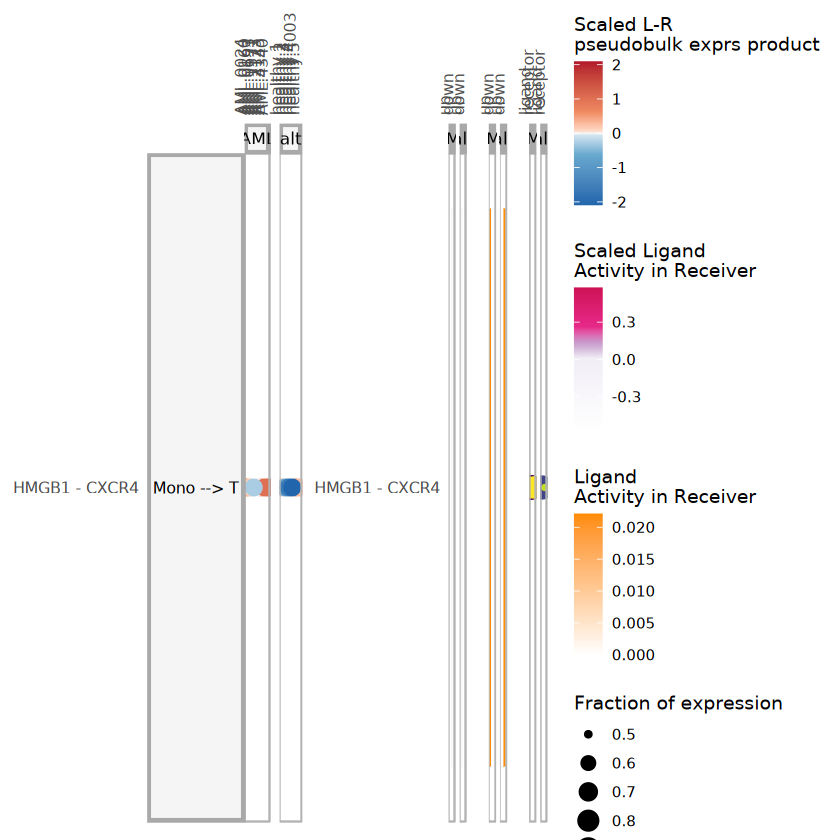

In [213]:
plot_oi = make_sample_lr_prod_activity_plots(
  multinichenet_output$prioritization_tables, 
  one)
plot_oi

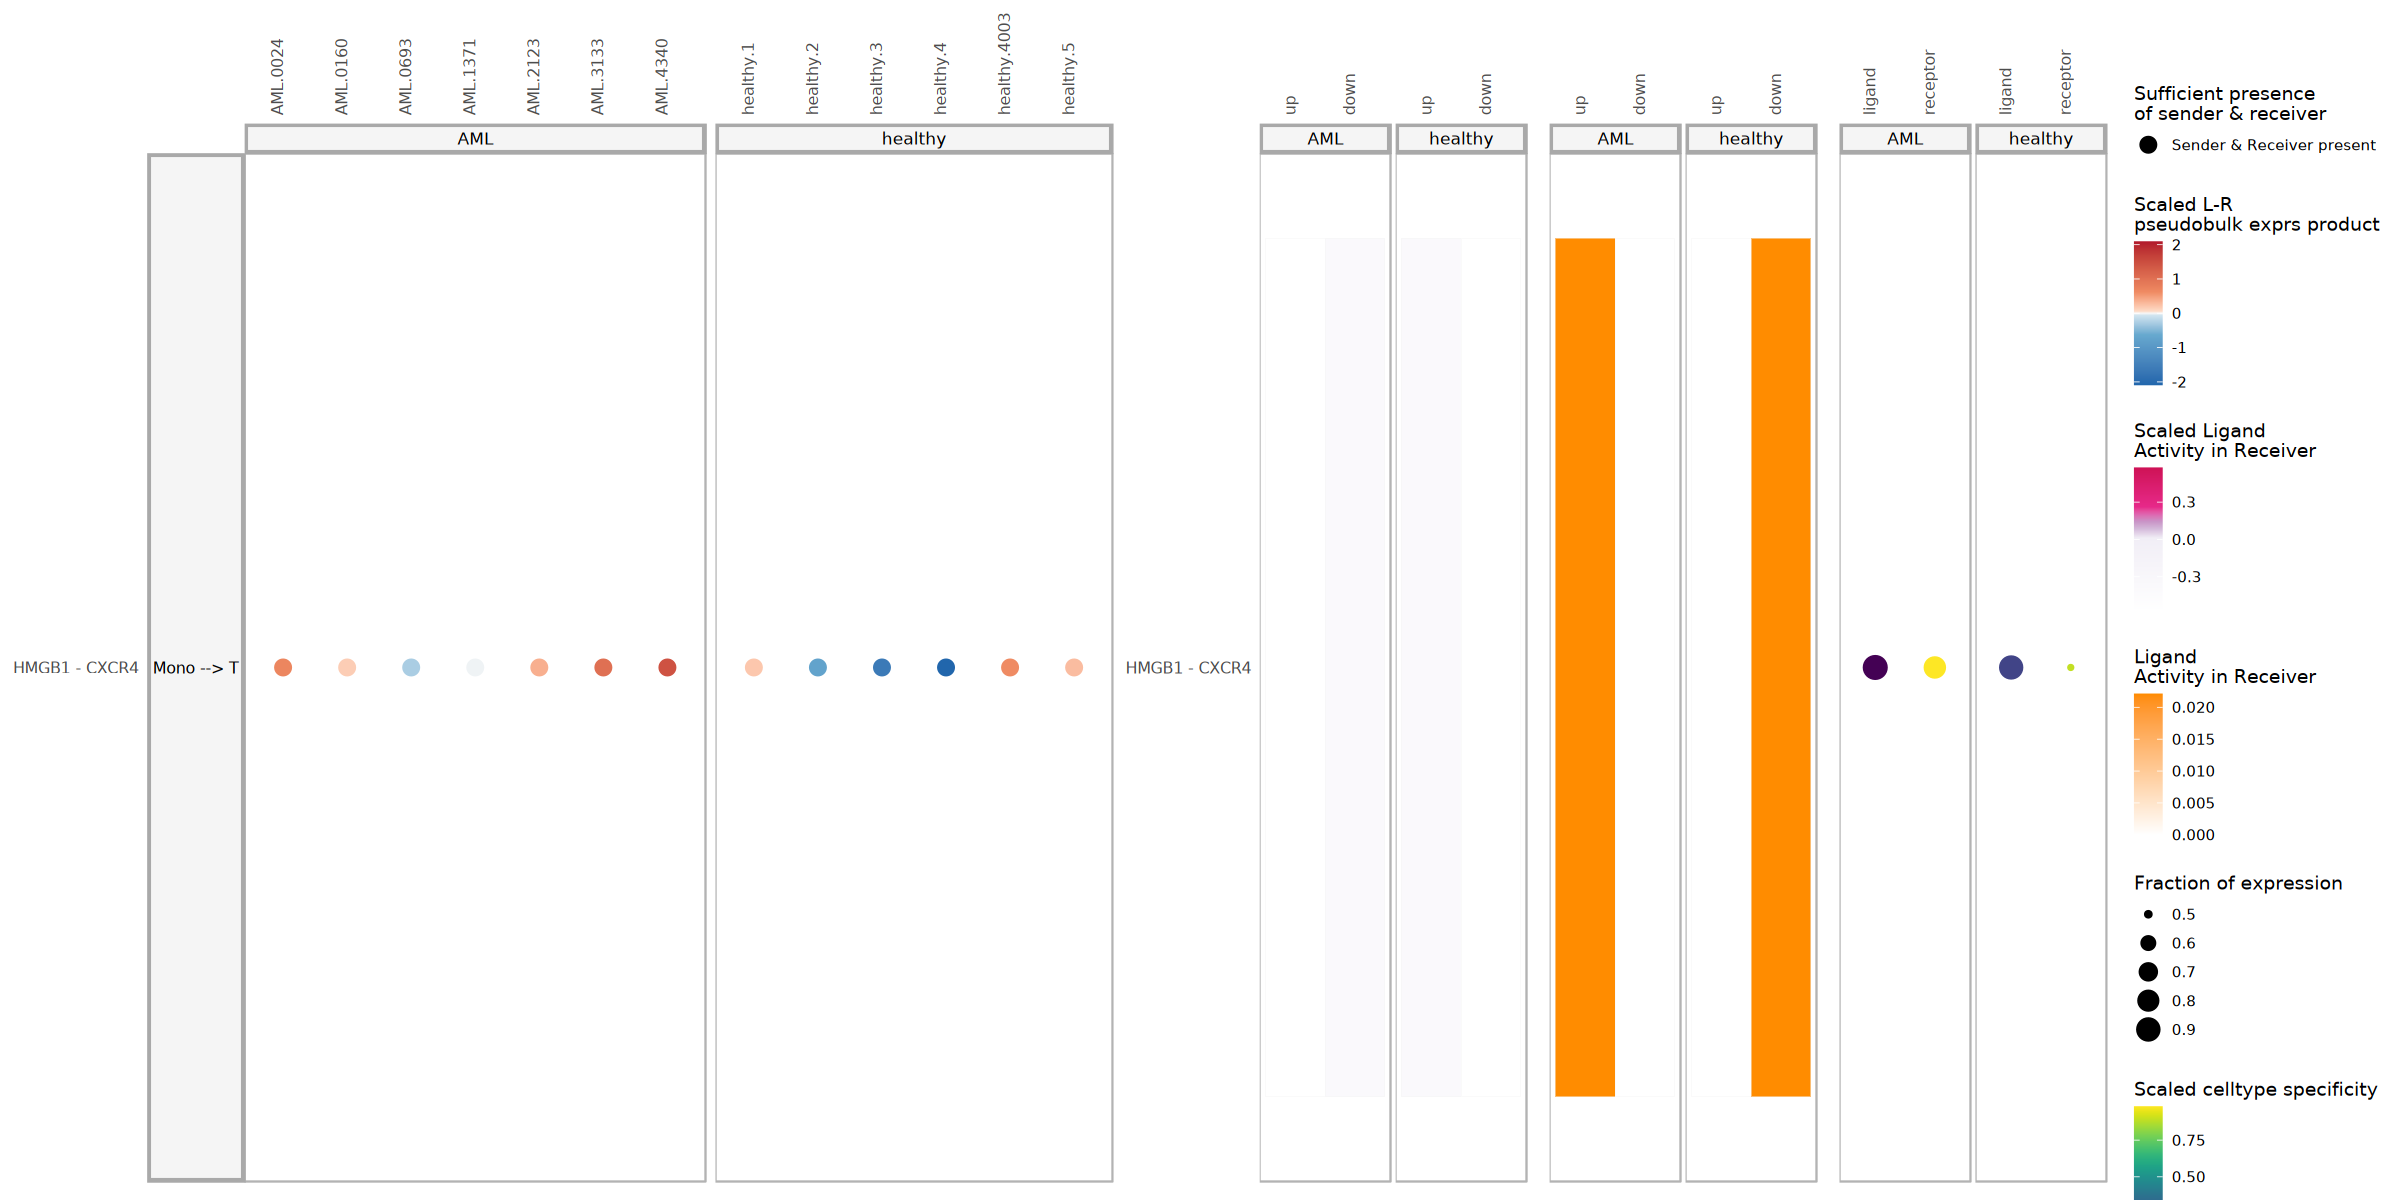

In [215]:
options(repr.plot.width=20, repr.plot.height=10)
plot_oi

In [43]:
# df[duplicated(df$interaction_ID),]

In [87]:
multinichenet_output$celltype_info$frq_df %>% head()

gene,sample,fraction_sample,celltype,group,expressed_sample
<chr>,<chr>,<dbl>,<chr>,<chr>,<lgl>
A4GALT,AML.0024,0.04366171,Mono,AML,FALSE
AAK1,AML.0024,0.64758760,Mono,AML,TRUE
ABCA1,AML.0024,0.04402862,Mono,AML,FALSE
ABCA2,AML.0024,0.01339204,Mono,AML,FALSE
ABCA7,AML.0024,0.08824069,Mono,AML,FALSE
ABCB10,AML.0024,0.04934874,Mono,AML,FALSE


In [88]:
sample_fr = multinichenet_output$celltype_info$frq_df

In [89]:
head(sample_fr[sample_fr$expressed_sample == TRUE & (sample_fr$gene %in% sample_df$ligand),])

gene,sample,fraction_sample,celltype,group,expressed_sample
<chr>,<chr>,<dbl>,<chr>,<chr>,<lgl>
ACTR2,AML.0024,0.8589250,Mono,AML,TRUE
ADAM10,AML.0024,0.5281600,Mono,AML,TRUE
ADAM15,AML.0024,0.1717116,Mono,AML,TRUE
ADAM17,AML.0024,0.5598973,Mono,AML,TRUE
ADAM9,AML.0024,0.1368556,Mono,AML,TRUE
ADM,AML.0024,0.6989543,Mono,AML,TRUE


In [93]:
# sample_df[sample_df$interaction_ID == "Mono:ADAM17_DC:ITGA5",]

In [169]:
df[df$interaction_ID == "Mono:ADAM17_DC:ITGA5",]

contrast,group,sender,receiver,ligand,receptor,lr_interaction,id,scaled_lfc_ligand,scaled_p_val_ligand_adapted,scaled_lfc_receptor,scaled_p_val_receptor_adapted,max_scaled_activity,scaled_pb_ligand,scaled_pb_receptor,fraction_expressing_ligand_receptor,prioritization_score,top_group,interaction_ID
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
AML-healthy,AML,Mono,DC,ADAM17,ITGA5,ADAM17_ITGA5,ADAM17_ITGA5_Mono_DC,0.91568966,0.97241379,0.96820934,0.95069204,1.0010000,1.00100,0.9257011,0.7142857,0.9242482,AML,Mono:ADAM17_DC:ITGA5
healthy-AML,healthy,Mono,DC,ADAM17,ITGA5,ADAM17_ITGA5,ADAM17_ITGA5_Mono_DC,0.08465517,0.02793103,0.03222318,0.04974048,0.1096152,0.73024,0.7466812,0.5000000,0.3639685,AML,Mono:ADAM17_DC:ITGA5


In [170]:
pass_sample_qc[pass_sample_qc$interaction_ID == "Mono:ADAM17_DC:ITGA5",]

contrast,group,sender,receiver,ligand,receptor,lr_interaction,id,scaled_lfc_ligand,scaled_p_val_ligand_adapted,scaled_lfc_receptor,scaled_p_val_receptor_adapted,max_scaled_activity,scaled_pb_ligand,scaled_pb_receptor,fraction_expressing_ligand_receptor,prioritization_score,top_group,interaction_ID
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
AML-healthy,AML,Mono,DC,ADAM17,ITGA5,ADAM17_ITGA5,ADAM17_ITGA5_Mono_DC,0.9156897,0.9724138,0.9682093,0.950692,1.001,1.001,0.9257011,0.7142857,0.9242482,AML,Mono:ADAM17_DC:ITGA5


In [96]:
sample_df_frac = sample_df[sample_df$fraction_ligand > 0.1,]

In [97]:
sample_df_frac = sample_df_frac[sample_df_frac$fraction_receptor > 0.1,]

In [98]:
df[df$interaction_ID == "Ery:CD55_HSPC:ADGRE5",]

contrast,group,sender,receiver,ligand,receptor,lr_interaction,id,scaled_lfc_ligand,scaled_p_val_ligand_adapted,scaled_lfc_receptor,scaled_p_val_receptor_adapted,max_scaled_activity,scaled_pb_ligand,scaled_pb_receptor,fraction_expressing_ligand_receptor,prioritization_score,top_group,interaction_ID
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
AML-healthy,AML,Ery,HSPC,CD55,ADGRE5,CD55_ADGRE5,CD55_ADGRE5_Ery_HSPC,0.94172414,0.98551724,0.992647059,0.997837370,0.4367215,0.4714832,0.7978863,0.8571429,0.7536828,AML,Ery:CD55_HSPC:ADGRE5
healthy-AML,healthy,Ery,HSPC,CD55,ADGRE5,CD55_ADGRE5,CD55_ADGRE5_Ery_HSPC,0.05862069,0.01482759,0.007785467,0.002595156,0.7713466,0.0010000,0.3239037,1.0000000,0.3563608,AML,Ery:CD55_HSPC:ADGRE5


In [100]:
pass_sample_qc[pass_sample_qc$interaction_ID == "Ery:CD55_HSPC:ADGRE5",]

contrast,group,sender,receiver,ligand,receptor,lr_interaction,id,scaled_lfc_ligand,scaled_p_val_ligand_adapted,scaled_lfc_receptor,scaled_p_val_receptor_adapted,max_scaled_activity,scaled_pb_ligand,scaled_pb_receptor,fraction_expressing_ligand_receptor,prioritization_score,top_group,interaction_ID
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
AML-healthy,AML,Ery,HSPC,CD55,ADGRE5,CD55_ADGRE5,CD55_ADGRE5_Ery_HSPC,0.9417241,0.9855172,0.9926471,0.9978374,0.4367215,0.4714832,0.7978863,0.8571429,0.7536828,AML,Ery:CD55_HSPC:ADGRE5


In [111]:
# sample_df_frac[sample_df_frac$sample == "AML.0024" & sample_df_frac$ligand == "ACTR2",]

In [22]:
multinichenet_output$celltype_info$avg_df_group %>% head()

group,celltype,gene,average_group
<chr>,<chr>,<chr>,<dbl>
AML,B,A4GALT,0.00000000
AML,B,AAK1,0.04388065
AML,B,ABCA1,0.05666554
AML,B,ABCA2,0.01136996
AML,B,ABCA7,0.07875944
AML,B,ABCB10,0.02625633


In [23]:
multinichenet_output$celltype_info$frq_df_group %>% head()

group,celltype,gene,fraction_group
<chr>,<chr>,<chr>,<dbl>
AML,B,A4GALT,0.000000000
AML,B,AAK1,0.036475661
AML,B,ABCA1,0.041873706
AML,B,ABCA2,0.007814934
AML,B,ABCA7,0.059128245
AML,B,ABCB10,0.022805583


In [101]:
multinichenet_output$celltype_info$rel_abundance_df %>% head()

group,celltype,rel_abundance_scaled
<chr>,<chr>,<dbl>
AML,B,0.2605748
healthy,B,0.7414252
AML,DC,0.1162430
healthy,DC,0.8857570
AML,Ery,0.7946632
healthy,Ery,0.2073368


In [103]:
# multinichenet_output$celltype_info$rel_abundance_df

In [104]:
celltype_de = multinichenet_output$celltype_de

In [108]:
celltype_de_aml = celltype_de[celltype_de$contrast =="AML-healthy",]

In [110]:
head(celltype_de_aml)

gene,cluster_id,logFC,logCPM,F,p_val,p_adj.loc,p_adj,contrast
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
AAK1,Mono,0.767,7.71,11.200,0.0039,0.253,0.253,AML-healthy
ABCA1,Mono,0.444,6.60,0.373,0.5500,0.861,0.861,AML-healthy
ABHD14B,Mono,0.680,5.98,3.890,0.0652,0.494,0.494,AML-healthy
ABHD5,Mono,-0.650,7.19,4.040,0.0610,0.485,0.485,AML-healthy
ABTB1,Mono,-0.155,6.29,0.264,0.6140,0.889,0.889,AML-healthy
AC002558.3,Mono,0.391,5.90,2.220,0.4060,0.797,0.797,AML-healthy


In [ ]:
# pass_sample_qc = df_filtered[!duplicated(df_filtered$id),]

In [174]:
pass_sample_qc <- pass_sample_qc %>%
  left_join(
    celltype_de_aml %>%
      select(cluster_id, gene, p_val, logFC) %>%
      rename(sender = cluster_id,
             ligand = gene,
             ligand_p_val = p_val,
             ligand_logFC = logFC),
    by = c("ligand", "sender")
  ) %>%
  # receptor stats
  left_join(
    celltype_de_aml %>%
      select(cluster_id, gene, p_val, logFC) %>%
      rename(receiver = cluster_id,
             receptor = gene,
             receptor_p_val = p_val,
             receptor_logFC = logFC),
    by = c("receptor", "receiver")
  )

In [175]:
celltype_de_aml[celltype_de_aml$gene=="CAP1",]

gene,cluster_id,logFC,logCPM,F,p_val,p_adj.loc,p_adj,contrast
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
CAP1,Mono,0.00809,8.78,0.00100,0.9750,0.995,0.995,AML-healthy
CAP1,Gran,-0.27200,8.66,1.74000,0.2040,0.655,0.655,AML-healthy
CAP1,T,-0.12800,8.24,0.13200,0.7200,0.905,0.905,AML-healthy
CAP1,NK,-0.23000,8.48,0.35600,0.5590,0.939,0.939,AML-healthy
CAP1,B,-0.56200,7.65,3.02000,0.0985,0.458,0.458,AML-healthy
CAP1,HSPC,0.08630,7.73,0.16500,0.6890,0.836,0.836,AML-healthy
CAP1,Ery,-0.02080,6.61,0.00499,0.9440,0.980,0.980,AML-healthy
CAP1,DC,-0.13800,8.60,0.15000,0.7040,0.930,0.930,AML-healthy


In [176]:
pass_sample_qc[pass_sample_qc$receptor == "CAP1",]

contrast,group,sender,receiver,ligand,receptor,lr_interaction,id,scaled_lfc_ligand,scaled_p_val_ligand_adapted,⋯,scaled_pb_ligand,scaled_pb_receptor,fraction_expressing_ligand_receptor,prioritization_score,top_group,interaction_ID,ligand_p_val,ligand_logFC,receptor_p_val,receptor_logFC
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
healthy-AML,healthy,Gran,Gran,RETN,CAP1,RETN_CAP1,RETN_CAP1_Gran_Gran,0.9824138,0.9631034,⋯,1.0010000,1.00100000,1.0000000,0.9483442,healthy,Gran:RETN_Gran:CAP1,0.00422,-1.700,0.2040,-0.27200
healthy-AML,healthy,Gran,DC,RETN,CAP1,RETN_CAP1,RETN_CAP1_Gran_DC,0.9824138,0.9631034,⋯,1.0010000,0.92055930,1.0000000,0.9151871,healthy,Gran:RETN_DC:CAP1,0.00422,-1.700,0.7040,-0.13800
healthy-AML,healthy,Mono,Gran,RETN,CAP1,RETN_CAP1,RETN_CAP1_Mono_Gran,0.8801724,0.7356897,⋯,0.8169314,1.00100000,1.0000000,0.8901948,healthy,Mono:RETN_Gran:CAP1,0.30900,-0.702,0.2040,-0.27200
healthy-AML,healthy,Mono,DC,RETN,CAP1,RETN_CAP1,RETN_CAP1_Mono_DC,0.8801724,0.7356897,⋯,0.8169314,0.92055930,1.0000000,0.8570377,healthy,Mono:RETN_DC:CAP1,0.30900,-0.702,0.7040,-0.13800
healthy-AML,healthy,Gran,Mono,RETN,CAP1,RETN_CAP1,RETN_CAP1_Gran_Mono,0.9824138,0.9631034,⋯,1.0010000,0.94769245,1.0000000,0.8524955,healthy,Gran:RETN_Mono:CAP1,0.00422,-1.700,0.9750,0.00809
healthy-AML,healthy,Gran,T,RETN,CAP1,RETN_CAP1,RETN_CAP1_Gran_T,0.9824138,0.9631034,⋯,1.0010000,0.61120973,1.0000000,0.8119696,healthy,Gran:RETN_T:CAP1,0.00422,-1.700,0.7200,-0.12800
healthy-AML,healthy,Mono,Mono,RETN,CAP1,RETN_CAP1,RETN_CAP1_Mono_Mono,0.8801724,0.7356897,⋯,0.8169314,0.94769245,1.0000000,0.7943462,healthy,Mono:RETN_Mono:CAP1,0.30900,-0.702,0.9750,0.00809
healthy-AML,healthy,Gran,B,RETN,CAP1,RETN_CAP1,RETN_CAP1_Gran_B,0.9824138,0.9631034,⋯,1.0010000,0.43584177,1.0000000,0.7835378,healthy,Gran:RETN_B:CAP1,0.00422,-1.700,0.0985,-0.56200
healthy-AML,healthy,Gran,NK,RETN,CAP1,RETN_CAP1,RETN_CAP1_Gran_NK,0.9824138,0.9631034,⋯,1.0010000,0.69734303,0.8333333,0.7763179,healthy,Gran:RETN_NK:CAP1,0.00422,-1.700,0.5590,-0.23000


In [177]:
target_de = multinichenet_output$ligand_activities_targets_DEgenes$ligand_activities

In [178]:
target_de = target_de[!is.na(target_de$target),]

In [179]:
head(target_de)

ligand,activity,contrast,target,ligand_target_weight,receiver,direction_regulation,activity_scaled
<chr>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<fct>,<dbl>
S100A10,4.912979e-04,healthy-AML,ALOX5AP,0.001807196,B,up,0.1604853
S100A10,4.912979e-04,healthy-AML,LSM10,0.001480537,B,up,0.1604853
S100A10,4.912979e-04,healthy-AML,STMN1,0.001968730,B,up,0.1604853
S100A10,4.912979e-04,healthy-AML,TBC1D1,0.002722509,B,up,0.1604853
JAG2,-3.137139e-05,healthy-AML,ALOX5AP,0.012158275,B,up,-0.3840216
JAG2,-3.137139e-05,healthy-AML,CXXC5,0.009383289,B,up,-0.3840216


In [180]:
df = multinichenet_output$prioritization_tables$group_prioritization_tbl
df$interaction_ID <- paste0(df$sender, ":", df$ligand, "_", df$receiver, ":", df$receptor)

In [181]:
head(celltype_de)

gene,cluster_id,logFC,logCPM,F,p_val,p_adj.loc,p_adj,contrast
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
AAK1,Mono,-0.767,7.71,11.200,0.0039,0.253,0.253,healthy-AML
ABCA1,Mono,-0.444,6.60,0.373,0.5500,0.861,0.861,healthy-AML
ABHD14B,Mono,-0.680,5.98,3.890,0.0652,0.494,0.494,healthy-AML
ABHD5,Mono,0.650,7.19,4.040,0.0610,0.485,0.485,healthy-AML
ABTB1,Mono,0.155,6.29,0.264,0.6140,0.889,0.889,healthy-AML
AC002558.3,Mono,-0.391,5.90,2.220,0.4060,0.797,0.797,healthy-AML


In [132]:
celltype_de_sig = celltype_de[celltype_de$p_val < 0.05,]

In [32]:
dim(target_de)

[1] 584192      8

In [33]:
dim(target_de[target_de$target %in% celltype_de_sig$gene,])

[1] 584190      8

In [34]:
dim(df)

[1] 28294    19

In [35]:
dim(df[!duplicated(df$interaction_ID),])

[1] 14147    19

In [133]:
df_filtered[df_filtered$interaction_ID == "Mono:HMGB1_T:CXCR4",]

contrast,group,sender,receiver,ligand,receptor,lr_interaction,id,scaled_lfc_ligand,scaled_p_val_ligand_adapted,scaled_lfc_receptor,scaled_p_val_receptor_adapted,max_scaled_activity,scaled_pb_ligand,scaled_pb_receptor,fraction_expressing_ligand_receptor,prioritization_score,top_group,interaction_ID
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
AML-healthy,AML,Mono,T,HMGB1,CXCR4,HMGB1_CXCR4,HMGB1_CXCR4_Mono_T,0.4493103,0.3855172,0.8910035,0.95761246,0.3575952,0.0010000,0.9798333,1,0.6133584,AML,Mono:HMGB1_T:CXCR4
healthy-AML,healthy,Mono,T,HMGB1,CXCR4,HMGB1_CXCR4,HMGB1_CXCR4_Mono_T,0.5510345,0.6148276,0.1094291,0.04282007,0.4022158,0.1971757,0.8912183,1,0.5249442,AML,Mono:HMGB1_T:CXCR4


In [37]:
df[df$interaction_ID=="DC:CD14_Ery:PLXND1",]

contrast,group,sender,receiver,ligand,receptor,lr_interaction,id,scaled_lfc_ligand,scaled_p_val_ligand_adapted,scaled_lfc_receptor,scaled_p_val_receptor_adapted,max_scaled_activity,scaled_pb_ligand,scaled_pb_receptor,fraction_expressing_ligand_receptor,prioritization_score,top_group,interaction_ID
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
healthy-AML,healthy,DC,Ery,CD14,PLXND1,CD14_PLXND1,CD14_PLXND1_DC_Ery,0.98327586,0.94086207,0.90506055,0.92647059,0.4357610,0.6384905,0.8342073,0.6666667,0.7421600,healthy,DC:CD14_Ery:PLXND1
AML-healthy,AML,DC,Ery,CD14,PLXND1,CD14_PLXND1,CD14_PLXND1_DC_Ery,0.01706897,0.05948276,0.09537197,0.07396194,0.4816696,0.2968620,0.1896092,0.0000000,0.1818473,healthy,DC:CD14_Ery:PLXND1


In [134]:
# sample_df[sample_df$interaction_ID=="DC:CD14_Ery:PLXND1",]

In [182]:
pass_sample_qc$min_pval <- pmin(pass_sample_qc$ligand_p_val, pass_sample_qc$receptor_p_val)
max(pass_sample_qc$min_pval)

[1] 0.994

In [183]:
pass_sample_qc_sign = pass_sample_qc[pass_sample_qc$min_pval < 0.05,]

In [184]:
dim(pass_sample_qc_sign)

[1] 3987   24

In [185]:
pass_sample_qc[duplicated(pass_sample_qc$interaction_ID),]

Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
“number of rows of result is not a multiple of vector length (arg 2)”
Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
“number of rows of result is not a multiple of vector length (arg 2)”
Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
“number of rows of result is not a multiple of vector length (arg 2)”
Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
“number of rows of result is not a multiple of vector length (arg 2)”


contrast,group,sender,receiver,ligand,receptor,lr_interaction,id,scaled_lfc_ligand,scaled_p_val_ligand_adapted,⋯,scaled_pb_receptor,fraction_expressing_ligand_receptor,prioritization_score,top_group,interaction_ID,ligand_p_val,ligand_logFC,receptor_p_val,receptor_logFC,min_pval
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>


In [186]:
pass_sample_qc <- pass_sample_qc %>%
  mutate(sign = interaction_ID %in% pass_sample_qc_sign$interaction_ID)

In [187]:
table(pass_sample_qc$sign)


FALSE  TRUE 
 6303  3987 

In [48]:
df = df[df$contrast == "AML-healthy",]

In [43]:
dim(df[df$contrast == "AML-healthy",])

[1] 14147    19

In [41]:
de_dup_df = df[!duplicated(df$interaction_ID),]

In [42]:
dim(de_dup_df)

[1] 14147    19

In [56]:
dim(de_dup_df[de_dup_df$fraction_expressing_ligand_receptor >= 0.6,])

[1] 6348   19

In [69]:
de_dup_df = df[!duplicated(df$interaction_ID),]
de_dup_df$min_pval <- pmin(de_dup_df$scaled_p_val_ligand_adapted, de_dup_df$scaled_p_val_receptor_adapted)

In [70]:
dim(de_dup_df[de_dup_df$min_pval < 0.05,])

[1] 932  20

In [54]:
df_sig = de_dup_df[de_dup_df$min_pval < 0.05,]

In [44]:
unique(df$contrast)

[1] "AML-healthy"

In [71]:
df[df$interaction_ID == "Mono:HMGB1_T:CXCR4",]

contrast,group,sender,receiver,ligand,receptor,lr_interaction,id,scaled_lfc_ligand,scaled_p_val_ligand_adapted,scaled_lfc_receptor,scaled_p_val_receptor_adapted,max_scaled_activity,scaled_pb_ligand,scaled_pb_receptor,fraction_expressing_ligand_receptor,prioritization_score,top_group,interaction_ID
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
AML-healthy,AML,Mono,T,HMGB1,CXCR4,HMGB1_CXCR4,HMGB1_CXCR4_Mono_T,0.4493103,0.3855172,0.8910035,0.9576125,0.3575952,0.001,0.9798333,1,0.6133584,AML,Mono:HMGB1_T:CXCR4


In [72]:
df_sig[df_sig$interaction_ID == "Mono:HMGB1_T:CXCR4",]

ERROR: Error: object 'df_sig' not found


In [48]:
dim(df[df$interaction_ID %in% sample_df$interaction_ID,])

[1] 27510    19

In [47]:
dim(de_dup_df[de_dup_df$interaction_ID %in% sample_df$interaction_ID,])

[1] 27510    19

In [57]:
anno_interactions = de_dup_df

In [188]:
anno_interactions = pass_sample_qc

In [189]:
anno_interactions = rename(anno_interactions, sender_celltype = sender, sender_gene = ligand, receiver_celltype = receiver, receiver_gene = receptor)

In [147]:
# idx_down <- anno_interactions$ligand_receptor_lfc_avg < 0
# idx_up <- anno_interactions$ligand_receptor_lfc_avg > 0

# anno_interactions$direction <- NA
# anno_interactions$direction[idx_down] <- "down"
# anno_interactions$direction[idx_up] <- "up"

In [190]:
library(dplyr)
library(tidyr)

In [191]:
sample_df_frac <- sample_df_frac %>%
  arrange(sample, interaction_ID)

In [192]:
anno_interactions = pass_sample_qc

In [193]:
df_binary <- sample_df_frac %>%
  select(sample, interaction_ID) %>%
  mutate(value = 1) %>%
  distinct() %>%
  pivot_wider(
    names_from = sample,
    values_from = value,
    values_fill = 0
  )

In [153]:
idx_case <- grepl("AML",colnames(df_binary))
idx_control <- grepl("healthy",colnames(df_binary))


In [194]:
df_binary_sig = df_binary[df_binary$interaction_ID %in% anno_interactions$interaction_ID,]

In [195]:
dim(df_binary_sig)

[1] 10290    14

In [196]:
dim(anno_interactions)

[1] 10290    25

In [89]:
# df_binary[,idx_control]

In [157]:
head(anno_interactions)

contrast,group,sender,receiver,ligand,receptor,lr_interaction,id,scaled_lfc_ligand,scaled_p_val_ligand_adapted,⋯,fraction_expressing_ligand_receptor,prioritization_score,top_group,interaction_ID,ligand_p_val,ligand_logFC,receptor_p_val,receptor_logFC,min_pval,sign
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
healthy-AML,healthy,Gran,Gran,RETN,CAP1,RETN_CAP1,RETN_CAP1_Gran_Gran,0.9824138,0.9631034,⋯,1,0.9483442,healthy,Gran:RETN_Gran:CAP1,0.00422,-1.700,2.04e-01,-0.272,4.22e-03,TRUE
AML-healthy,AML,B,B,LGALS1,CD69,LGALS1_CD69,LGALS1_CD69_B_B,0.9558621,0.9758621,⋯,1,0.9238217,AML,B:LGALS1_B:CD69,0.00159,1.170,1.48e-01,0.646,1.59e-03,TRUE
healthy-AML,healthy,Gran,Gran,RETN,TLR4,RETN_TLR4,RETN_TLR4_Gran_Gran,0.9824138,0.9631034,⋯,1,0.9178505,healthy,Gran:RETN_Gran:TLR4,0.00422,-1.700,5.30e-01,-0.220,4.22e-03,TRUE
healthy-AML,healthy,Gran,DC,RETN,CAP1,RETN_CAP1,RETN_CAP1_Gran_DC,0.9824138,0.9631034,⋯,1,0.9151871,healthy,Gran:RETN_DC:CAP1,0.00422,-1.700,7.04e-01,-0.138,4.22e-03,TRUE
AML-healthy,AML,Gran,HSPC,LGALS9,CD44,LGALS9_CD44,LGALS9_CD44_Gran_HSPC,0.8762069,0.9341379,⋯,1,0.9127041,AML,Gran:LGALS9_HSPC:CD44,0.01630,0.691,5.33e-06,1.420,5.33e-06,TRUE
AML-healthy,AML,Gran,B,LGALS9,CD44,LGALS9_CD44,LGALS9_CD44_Gran_B,0.8762069,0.9341379,⋯,1,0.9115855,AML,Gran:LGALS9_B:CD44,0.01630,0.691,6.83e-03,0.620,6.83e-03,TRUE


In [197]:
# reassign directions for NN
anno_interactions$direction_lig <- NA
anno_interactions$direction_rec <- NA

anno_interactions$direction_lig[!is.na(anno_interactions$ligand_logFC) & (anno_interactions$ligand_logFC < 0.5)] <- "down"
anno_interactions$direction_lig[!is.na(anno_interactions$ligand_logFC) & (anno_interactions$ligand_logFC > 0.5)] <- "up"

anno_interactions$direction_rec[!is.na(anno_interactions$receptor_logFC) & (anno_interactions$receptor_logFC < 0.5)] <- "down"
anno_interactions$direction_rec[!is.na(anno_interactions$receptor_logFC) & (anno_interactions$receptor_logFC > 0.5)] <- "up"

anno_interactions$direction_lig_rec <- paste(anno_interactions$direction_lig
                                            ,anno_interactions$direction_rec
                                            ,sep = "_")
idx_down <- (anno_interactions$direction_lig_rec == "down_NA") | (
    anno_interactions$direction_lig_rec == "NA_down") | (
    anno_interactions$direction_lig_rec == "down_down")
idx_up <- (anno_interactions$direction_lig_rec == "up_NA") | (
    anno_interactions$direction_lig_rec == "NA_up") | (
    anno_interactions$direction_lig_rec == "up_up")

anno_interactions$direction <- NA
anno_interactions$direction[idx_down] <- "down"
anno_interactions$direction[idx_up] <- "up"
anno_interactions$direction[!(idx_down | idx_up)] <- "ambigous"

In [198]:
table(anno_interactions$direction)


ambigous     down       up 
    2741     7277      272 

In [158]:
# # reassign directions for NN
# anno_interactions$direction_lig <- NA
# anno_interactions$direction_rec <- NA

# anno_interactions$direction_lig[!is.na(anno_interactions$scaled_lfc_ligand) & (anno_interactions$scaled_lfc_ligand < 0.5)] <- "down"
# anno_interactions$direction_lig[!is.na(anno_interactions$scaled_lfc_ligand) & (anno_interactions$scaled_lfc_ligand > 0.5)] <- "up"

# anno_interactions$direction_rec[!is.na(anno_interactions$scaled_lfc_receptor) & (anno_interactions$scaled_lfc_receptor < 0.5)] <- "down"
# anno_interactions$direction_rec[!is.na(anno_interactions$scaled_lfc_receptor) & (anno_interactions$scaled_lfc_receptor > 0.5)] <- "up"

# anno_interactions$direction_lig_rec <- paste(anno_interactions$direction_lig
#                                             ,anno_interactions$direction_rec
#                                             ,sep = "_")
# idx_down <- (anno_interactions$direction_lig_rec == "down_NA") | (
#     anno_interactions$direction_lig_rec == "NA_down") | (
#     anno_interactions$direction_lig_rec == "down_down")
# idx_up <- (anno_interactions$direction_lig_rec == "up_NA") | (
#     anno_interactions$direction_lig_rec == "NA_up") | (
#     anno_interactions$direction_lig_rec == "up_up")

# anno_interactions$direction <- NA
# anno_interactions$direction[idx_down] <- "down"
# anno_interactions$direction[idx_up] <- "up"
# anno_interactions$direction[!(idx_down | idx_up)] <- "ambigous"

ERROR: Error: object 'nn_interactions' not found


In [199]:
anno_interactions = anno_interactions %>%
  mutate(interaction_ID = gsub(".", "-", interaction_ID, fixed = TRUE))


df_binary_sig = df_binary_sig %>%
  mutate(interaction_ID = gsub(".", "-", interaction_ID, fixed = TRUE))

multinn = list()
multinn$anno_interactions = anno_interactions
multinn$weights = df_binary_sig



multinn$weights <- multinn$weights[
  match(multinn$anno_interactions$interaction_ID, 
        multinn$weights$interaction_ID),
]

save(multinn, file = "multinn.RData")